In [ ]:
#for splitting the dataframes

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# for calling the models

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


#for calling the model performance metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [4]:
import pandas as pd

# Load the uploaded dataset

epma2 = pd.read_excel('/content/dataset epma preprocessed1.xlsx',
                      sheet_name = 'Sheet1')

# Display the first few rows of the dataset to understand its structure
epma2.head()


,NiO,F,Cr2O3,Na2O,MnO,ZnO,FeO,K2O,CaO,SiO2,TiO2,V2O3,MgO,Al2O3,T
0,0.000000,0.098655,0.087694,0.435239,0.315789,0.000000,0.426921,0.000000,-0.086134,-0.595574,-0.130038,1.020490,-1.177918,0.593104,2
1,0.440476,0.040359,0.117397,0.375729,0.210526,0.000000,0.387392,0.000000,-0.614105,-0.442478,-0.325993,0.225537,-0.904376,0.375515,2
2,0.333333,0.053812,0.239038,0.249708,0.035088,0.102564,0.158591,0.050847,0.903376,-0.501964,0.472235,0.478476,0.231962,0.674571,2
3,0.000000,0.170404,0.147100,0.289965,0.180702,0.461538,0.148151,0.000000,-0.087882,-0.190238,0.881435,1.598638,0.104901,0.709633,3
4,0.261905,0.000000,0.578501,0.283547,0.075439,0.000000,0.098821,0.042373,-0.332637,0.514373,-0.470077,-0.677820,0.629792,-0.444826,1


#LinearDiscriminantAnalysis

In [5]:
#for splitting the dataframes
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# for calling the models
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


#for calling the model performance metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# Defining the dataframe into X features and y target label

X = epma2.drop(columns=['T'])
y = epma2['T']



# Split into training and testing sets in a stratified manner

#for splitting the dataframes

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,

                                                    stratify=y, #applying stratified splitting to ensure proportional representation of target classes in training and test sets.

                                                    random_state=42)


# Check the distribution of target labels in the train and test sets
train_distribution = y_train.value_counts(normalize=True)

test_distribution = y_test.value_counts(normalize=True)

train_distribution, test_distribution


(T
 2    0.440120
 1    0.383234
 3    0.176647
 Name: proportion, dtype: float64,
 T
 2    0.440476
 1    0.380952
 3    0.178571
 Name: proportion, dtype: float64)

In [6]:
from sklearn.model_selection import KFold, cross_val_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the LDA model
lda_model = LinearDiscriminantAnalysis()

# Set up K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform K-Fold Cross-Validation and evaluate performance

fold_accuracies = []

for train_index, test_index in kf.split(X, y):

    # Split data into training and testing for this fold

    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]

    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Train the LDA model

    lda_model.fit(X_train_fold, y_train_fold)

    # Make predictions on the test fold

    y_pred_fold = lda_model.predict(X_test_fold)

    # Evaluate accuracy for this fold

    fold_accuracy = accuracy_score(y_test_fold, y_pred_fold)

    fold_accuracies.append(fold_accuracy)

    # (Optional) Print performance metrics for this fold

    print(f"Fold Accuracy: {fold_accuracy:.4f}")

    print(f"Confusion Matrix:\n{confusion_matrix(y_test_fold, y_pred_fold)}")

    print(f"Classification Report:\n{classification_report(y_test_fold, y_pred_fold)}")


# Calculate the mean and standard deviation of accuracy across folds

mean_accuracy = sum(fold_accuracies) / len(fold_accuracies)

std_accuracy = (sum([(x - mean_accuracy)**2 for x in fold_accuracies]) / len(fold_accuracies))**0.5

print("\nCross-Validation Results:")

print(f"Mean Accuracy: {mean_accuracy:.4f}")

print(f"Standard Deviation of Accuracy: {std_accuracy:.4f}")


Fold Accuracy: 0.6905
Confusion Matrix:
[[21  7  4]
 [ 5 30  2]
 [ 5  3  7]]
Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.66      0.67        32
           2       0.75      0.81      0.78        37
           3       0.54      0.47      0.50        15

    accuracy                           0.69        84
   macro avg       0.66      0.64      0.65        84
weighted avg       0.68      0.69      0.69        84

Fold Accuracy: 0.8095
Confusion Matrix:
[[24  3  1]
 [ 3 36  2]
 [ 7  0  8]]
Classification Report:
              precision    recall  f1-score   support

           1       0.71      0.86      0.77        28
           2       0.92      0.88      0.90        41
           3       0.73      0.53      0.62        15

    accuracy                           0.81        84
   macro avg       0.79      0.76      0.76        84
weighted avg       0.82      0.81      0.81        84

Fold Accuracy: 0.7619
Confusion Matrix

In [12]:
# for calling the models

from sklearn.model_selection import KFold, cross_val_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis



#for calling the model performance metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# defining the function train_and_evaluate

# it takes the argument X_train_fold, y_train_fold, X_val_fold and y_val_fold

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    it Train and evaluate the model on a single fold using Logistic Regression.
    """
    # Train the LDA model

    lda_model.fit(X_train_fold, y_train_fold)

    # Validate the model # Make predictions on the test fold

    y_val_pred = lda_model.predict(X_val_fold) # prediction on X_val_fold

      # Evaluate accuracy for this fold

    accuracy = accuracy_score(y_val_fold, y_val_pred) # where y_val_pred = model.predict(X_val_fold)

    return accuracy

###########################################################################################################################

from sklearn.model_selection import StratifiedKFold, cross_val_score

fold_accuracies = []

fold_models = []  # Store models for each fold

# Define Stratified K-Fold as kf where,

kf = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)


# Loop through the folds
for fold, (train_index, val_index) in enumerate( kf.split( X_train, y_train ) ):

    # Split the data into training and validation subsets

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]

    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Call the training function

    accuracy = train_and_evaluate(X_train_fold,
                                  y_train_fold,
                                  X_val_fold,
                                  y_val_fold)

    fold_accuracies.append(accuracy)

    print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")


# Calculate the average accuracy across all folds

avg_accuracy = sum(fold_accuracies) / len(fold_accuracies)

print(f"Average CV Accuracy: {avg_accuracy:.4f}")




Fold 1 Accuracy: 0.7313
Fold 2 Accuracy: 0.7015
Fold 3 Accuracy: 0.7015
Fold 4 Accuracy: 0.7612
Fold 5 Accuracy: 0.7576
Average CV Accuracy: 0.7306


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Initialize lists to store metrics for each fold
fold_precisions = []
fold_recalls = []
fold_f1_scores = []

# Stratified K-Fold setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nCalculating Precision, Recall, and F1-Score for Each Fold:")

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Split data into training and testing for this fold
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Train the LDA model
    lda_model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred_fold = lda_model.predict(X_test_fold)

    # Calculate precision, recall, and F1-score for this fold
    fold_precision = precision_score(y_test_fold, y_pred_fold, average='weighted')
    fold_recall = recall_score(y_test_fold, y_pred_fold, average='weighted')
    fold_f1 = f1_score(y_test_fold, y_pred_fold, average='weighted')

    # Append metrics to respective lists
    fold_precisions.append(fold_precision)
    fold_recalls.append(fold_recall)
    fold_f1_scores.append(fold_f1)

    # Print metrics for this fold
    print(f"Fold {fold + 1}:")
    print(f"Precision: {fold_precision:.4f}")
    print(f"Recall: {fold_recall:.4f}")
    print(f"F1-Score: {fold_f1:.4f}\n")

# Calculate average metrics across all folds
avg_precision = sum(fold_precisions) / len(fold_precisions)
avg_recall = sum(fold_recalls) / len(fold_recalls)
avg_f1_score = sum(fold_f1_scores) / len(fold_f1_scores)

# Print average metrics
print("\nAverage Metrics Across All Folds:")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average F1-Score: {avg_f1_score:.4f}")



Calculating Precision, Recall, and F1-Score for Each Fold:
Fold 1:
Precision: 0.7268
Recall: 0.7262
F1-Score: 0.7185

Fold 2:
Precision: 0.7435
Recall: 0.7262
F1-Score: 0.7261

Fold 3:
Precision: 0.7413
Recall: 0.7381
F1-Score: 0.7290

Fold 4:
Precision: 0.7176
Recall: 0.7349
F1-Score: 0.7160

Fold 5:
Precision: 0.6046
Recall: 0.6265
F1-Score: 0.6062


Average Metrics Across All Folds:
Average Precision: 0.7067
Average Recall: 0.7104
Average F1-Score: 0.6992


In [20]:
from sklearn.metrics import confusion_matrix

# Initialize a list to store confusion matrices for each fold
fold_confusion_matrices = []

# Stratified K-Fold setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nConfusion Matrices for Each Fold:")

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    # Split data into training and testing for this fold
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Train the LDA model
    lda_model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred_fold = lda_model.predict(X_test_fold)

    # Calculate confusion matrix for this fold
    fold_cm = confusion_matrix(y_test_fold, y_pred_fold)

    # Append the confusion matrix to the list
    fold_confusion_matrices.append(fold_cm)

    # Print the confusion matrix for this fold
    print(f"Fold {fold + 1} Confusion Matrix:\n{fold_cm}\n")

# (Optional) If needed, the list `fold_confusion_matrices` contains all confusion matrices for further processing.



Confusion Matrices for Each Fold:
Fold 1 Confusion Matrix:
[[25  5  2]
 [ 6 30  1]
 [ 7  2  6]]

Fold 2 Confusion Matrix:
[[27  2  3]
 [ 7 27  3]
 [ 7  1  7]]

Fold 3 Confusion Matrix:
[[22  9  1]
 [ 3 33  1]
 [ 5  3  7]]

Fold 4 Confusion Matrix:
[[23  7  2]
 [ 2 34  1]
 [ 8  2  4]]

Fold 5 Confusion Matrix:
[[20  9  3]
 [ 6 29  1]
 [ 9  3  3]]



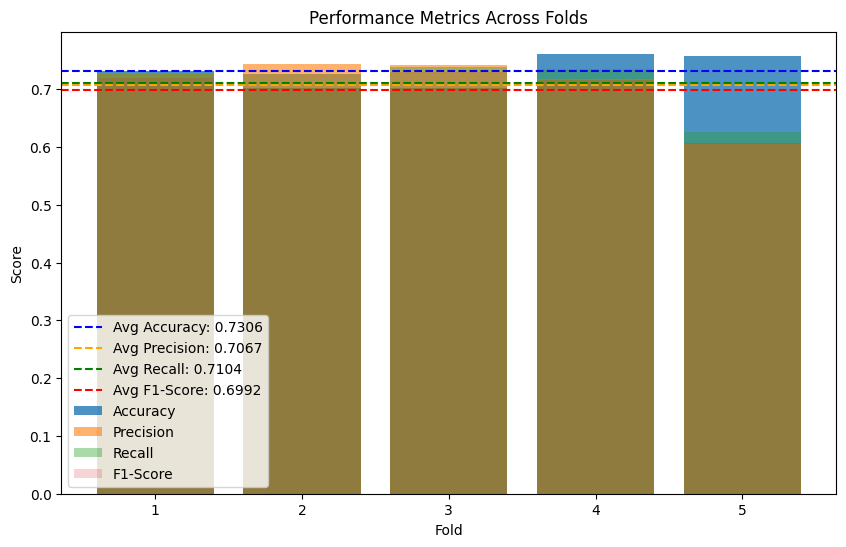

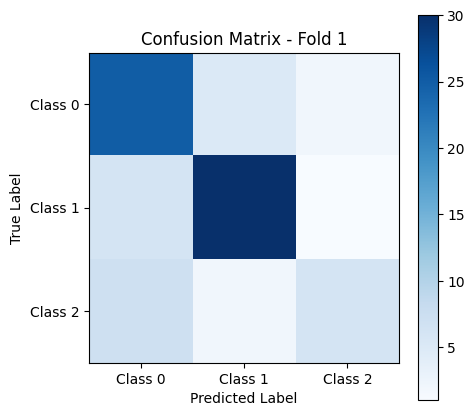

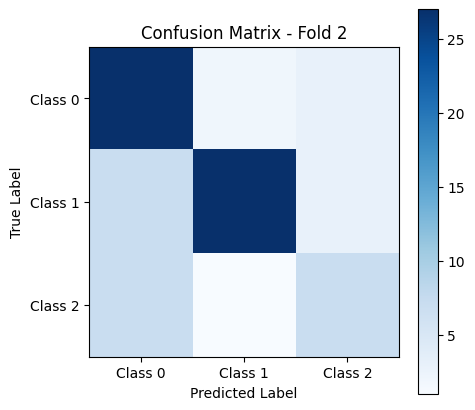

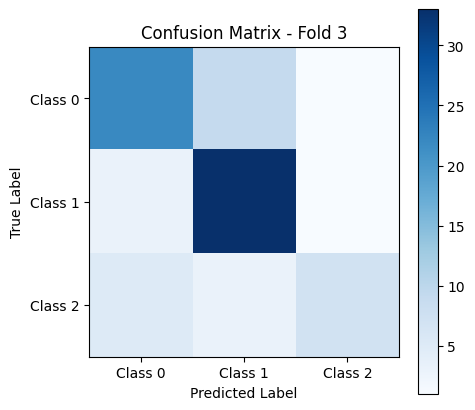

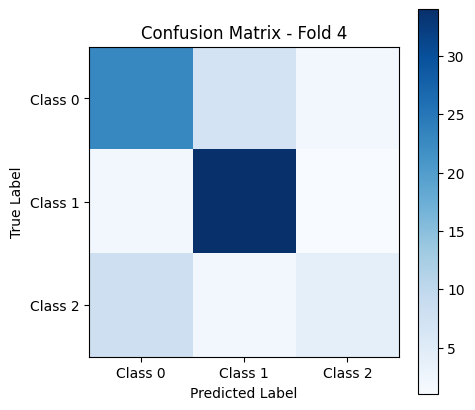

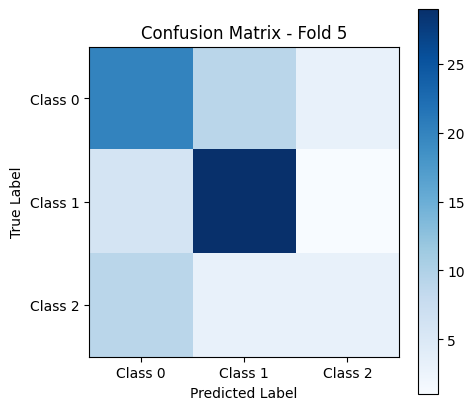

In [21]:
import matplotlib.pyplot as plt

# Plotting metrics for each fold

folds = range(1, len(fold_accuracies) + 1)

plt.figure(figsize=(10, 6))

# Bar chart for Accuracy, Precision, Recall, and F1-Score
plt.bar(folds, fold_accuracies, alpha=0.8, label='Accuracy')

plt.bar(folds, fold_precisions, alpha=0.6, label='Precision')
plt.bar(folds, fold_recalls, alpha=0.4, label='Recall')
plt.bar(folds, fold_f1_scores, alpha=0.2, label='F1-Score')

plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')

plt.axhline(avg_precision, color='orange', linestyle='--', label=f'Avg Precision: {avg_precision:.4f}')
plt.axhline(avg_recall, color='green', linestyle='--', label=f'Avg Recall: {avg_recall:.4f}')
plt.axhline(avg_f1_score, color='red', linestyle='--', label=f'Avg F1-Score: {avg_f1_score:.4f}')

# Labels and legend
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Performance Metrics Across Folds')
plt.xticks(folds)
plt.legend()
plt.show()


for fold, confusion in enumerate(fold_confusion_matrices, start=1):
    plt.figure(figsize=(5, 5))
    plt.imshow(confusion, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.colorbar()

    # Dynamically set ticks and labels based on the number of classes
    classes = range(confusion.shape[0])
    plt.xticks(classes, labels=[f'Class {i}' for i in classes])
    plt.yticks(classes, labels=[f'Class {i}' for i in classes])

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize the LDA model
lda_model = LinearDiscriminantAnalysis()

# Set up K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store evaluation metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
confusion_matrices = []

for train_index, test_index in kf.split(X, y):
    # Split data into training and testing for this fold
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Train the LDA model
    lda_model.fit(X_train_fold, y_train_fold)

    # Make predictions on the test fold
    y_pred_fold = lda_model.predict(X_test_fold)

    # Compute evaluation metrics
    accuracy_scores.append(accuracy_score(y_test_fold, y_pred_fold))
    precision_scores.append(precision_score(y_test_fold, y_pred_fold, average='weighted'))
    recall_scores.append(recall_score(y_test_fold, y_pred_fold, average='weighted'))
    f1_scores.append(f1_score(y_test_fold, y_pred_fold, average='weighted'))
    confusion_matrices.append(confusion_matrix(y_test_fold, y_pred_fold))

# Compute mean metrics across all folds
mean_accuracy = sum(accuracy_scores) / len(accuracy_scores)
mean_precision = sum(precision_scores) / len(precision_scores)
mean_recall = sum(recall_scores) / len(recall_scores)
mean_f1 = sum(f1_scores) / len(f1_scores)

# Print the results
print("Cross-Validation Metrics:")
print(f"Mean Accuracy: {mean_accuracy:.4f}")
print(f"Mean Precision: {mean_precision:.4f}")
print(f"Mean Recall: {mean_recall:.4f}")
print(f"Mean F1-Score: {mean_f1:.4f}")

print("\nConfusion Matrices for Each Fold:")
for i, cm in enumerate(confusion_matrices):
    print(f"Fold {i + 1}:\n{cm}\n")


Cross-Validation Metrics:
Mean Accuracy: 0.7295
Mean Precision: 0.7324
Mean Recall: 0.7295
Mean F1-Score: 0.7203

Confusion Matrices for Each Fold:
Fold 1:
[[21  7  4]
 [ 5 30  2]
 [ 5  3  7]]

Fold 2:
[[24  3  1]
 [ 3 36  2]
 [ 7  0  8]]

Fold 3:
[[28  7  1]
 [ 7 29  0]
 [ 4  1  7]]

Fold 4:
[[21  6  1]
 [ 3 33  0]
 [ 8  6  5]]

Fold 5:
[[24  9  3]
 [ 3 28  3]
 [ 7  2  4]]



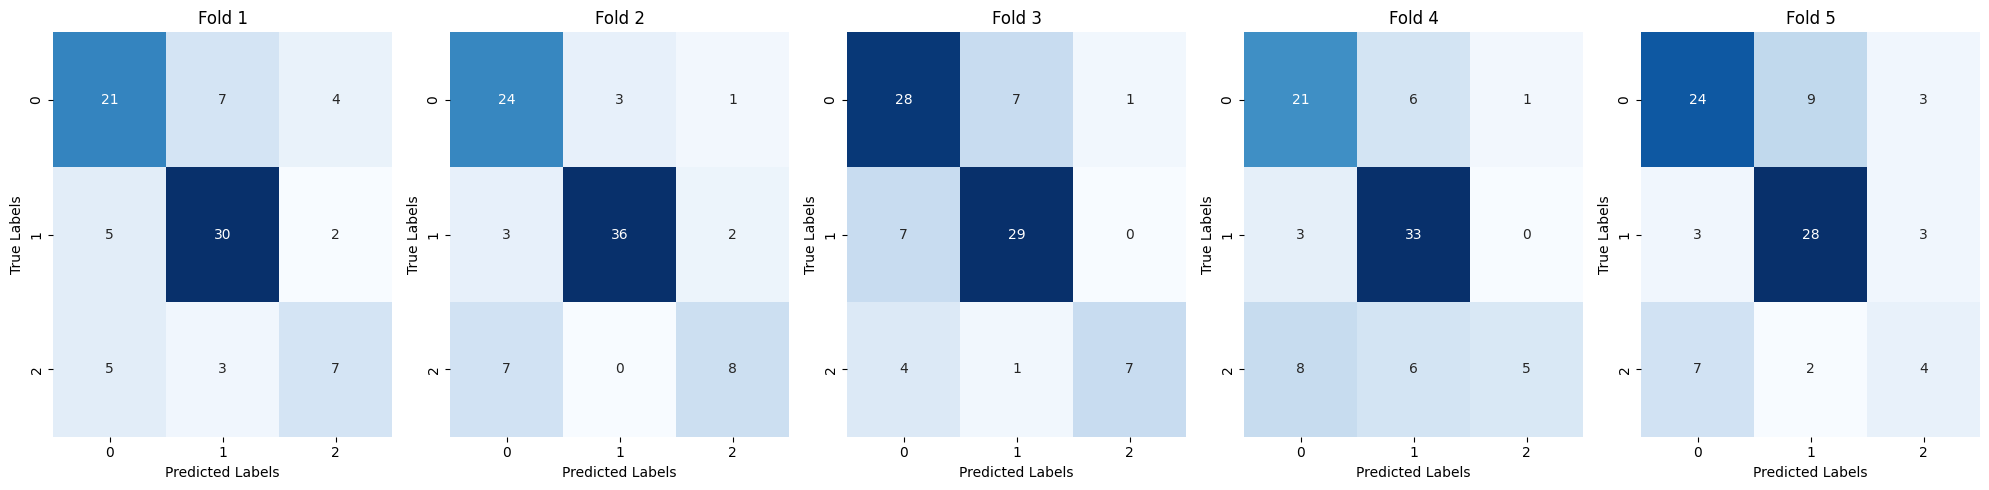

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Number of folds
n_folds = len(confusion_matrices)

# Create subplots
fig, axes = plt.subplots(1, n_folds, figsize=(20, 5))

# Plot each confusion matrix
for i, cm in enumerate(confusion_matrices):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i])
    axes[i].set_title(f"Fold {i + 1}")
    axes[i].set_xlabel("Predicted Labels")
    axes[i].set_ylabel("True Labels")

# Adjust layout and display the plots
plt.tight_layout()
plt.show()


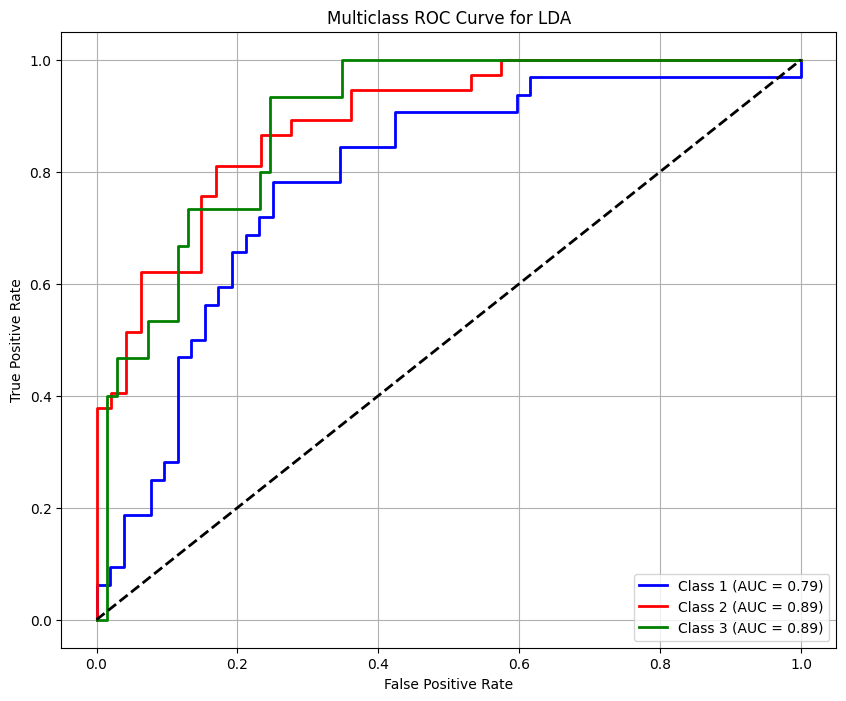

In [16]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle

# Binarize the output for ROC computation
y_binarized = label_binarize(y, classes=np.unique(y))
n_classes = y_binarized.shape[1]

# Initialize the LDA model for one-vs-rest classification
lda_ovr = OneVsRestClassifier(LinearDiscriminantAnalysis())

# Train-test split for ROC analysis
X_train, X_test, y_train, y_test = train_test_split(X, y_binarized, test_size=0.2, random_state=42)

# Fit the model and predict probabilities
lda_ovr.fit(X_train, y_train)
y_score = lda_ovr.decision_function(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = cycle(["blue", "red", "green", "purple", "orange"])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {i + 1} (AUC = {roc_auc[i]:.2f})")

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Formatting the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve for LDA")
plt.legend(loc="lower right")
plt.grid()
plt.show()


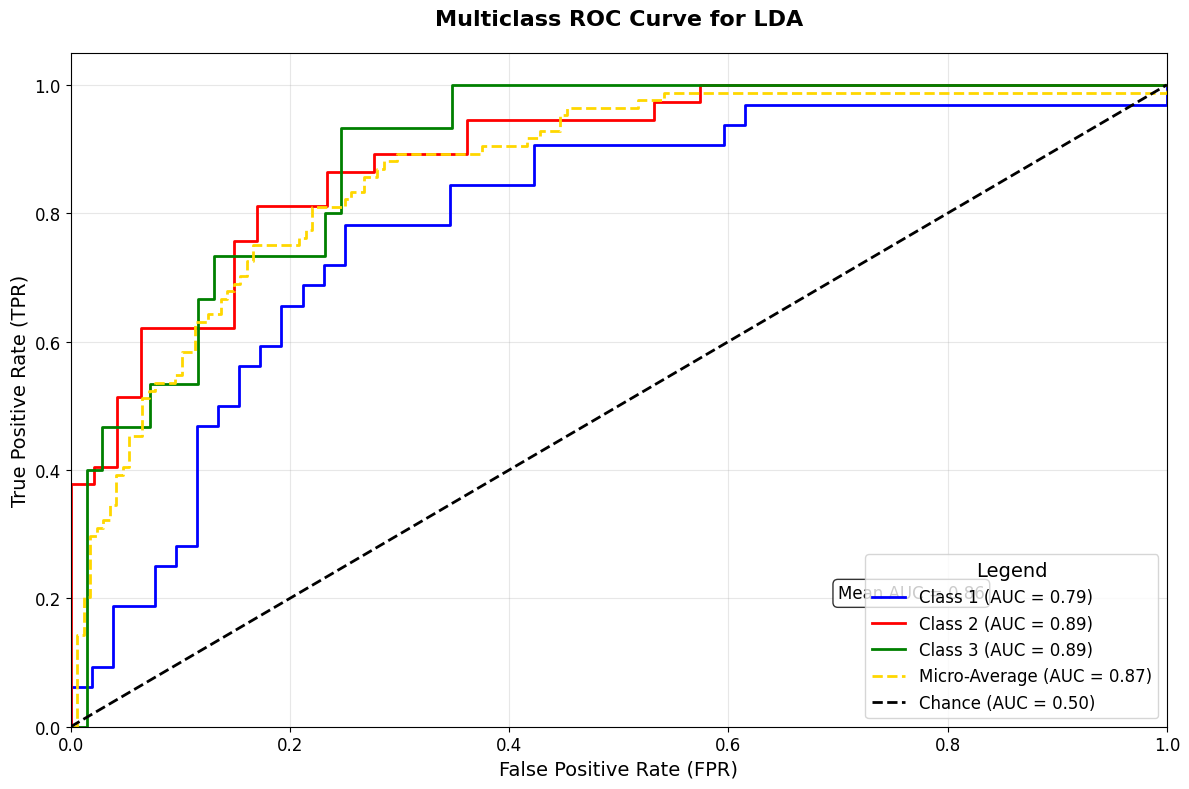

In [17]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np

# Binarize the output for ROC computation
y_binarized = label_binarize(y, classes=np.unique(y))
n_classes = y_binarized.shape[1]

# Initialize the LDA model for one-vs-rest classification
lda_ovr = OneVsRestClassifier(LinearDiscriminantAnalysis())

# Train-test split for ROC analysis
X_train, X_test, y_train, y_test = train_test_split(X, y_binarized, test_size=0.2, random_state=42)

# Fit the model and predict probabilities
lda_ovr.fit(X_train, y_train)
y_score = lda_ovr.decision_function(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(12, 8))
colors = cycle(["blue", "red", "green", "purple", "orange"])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {i + 1} (AUC = {roc_auc[i]:.2f})")

# Calculate and plot the micro-average ROC curve (optional for multiclass)
fpr_micro, tpr_micro, _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, color='gold', lw=2, linestyle='--',
         label=f"Micro-Average (AUC = {roc_auc_micro:.2f})")

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Chance (AUC = 0.50)")

# Add title and labels
plt.title("Multiclass ROC Curve for LDA", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("False Positive Rate (FPR)", fontsize=14)
plt.ylabel("True Positive Rate (TPR)", fontsize=14)
plt.legend(loc="lower right", fontsize=12, title="Legend", title_fontsize=14)
plt.grid(alpha=0.3)

# Add axis ticks and limits
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Add a summary box for overall performance
mean_auc = np.mean(list(roc_auc.values()))
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
plt.text(0.7, 0.2, f"Mean AUC = {mean_auc:.2f}", fontsize=12, bbox=props)

# Show the plot
plt.tight_layout()
plt.show()


#**DecisionTreeClassifier**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score ,GridSearchCV

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, mean_squared_error)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load dataset (assuming epma2 is already loaded as a DataFrame)
X = epma2.drop(columns=['T'])
y = epma2['T']

# Split into training and test sets(stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Initialize the decision tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=15,
                     shuffle=True,
                     random_state=42)

cv_scores = cross_val_score(dt_model,
                            X_train,
                            y_train,
                            cv= kf,
                            scoring='accuracy')


# Function to train and evaluate the model
def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    #Initialize the decision tree classifier

    dt_model = DecisionTreeClassifier(random_state=42)

    dt_model.fit(X_train_fold, y_train_fold)

    y_val_pred = dt_model.predict(X_val_fold)

    accuracy = accuracy_score(y_val_fold, y_val_pred)

    return accuracy, dt_model

# Print results
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))
print("Test Accuracy:", accuracy)


fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': []
}
best_model = None
best_accuracy = 0

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Validate additional metrics
    y_val_pred = model.predict(X_val_fold)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

# Average Metrics
avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")

# Save the best model
joblib.dump(best_model, 'best_random_forest_model.pkl')

# Plot Metrics
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.plot(folds, fold_accuracies, marker='o', label='Accuracy')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across Folds')
plt.legend()
plt.show()

# Confusion Matrix Visualization
for fold, confusion in enumerate(fold_metrics['confusion_matrices'], start=1):
    plt.figure(figsize=(5, 5))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Test Set Evaluation
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")

# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


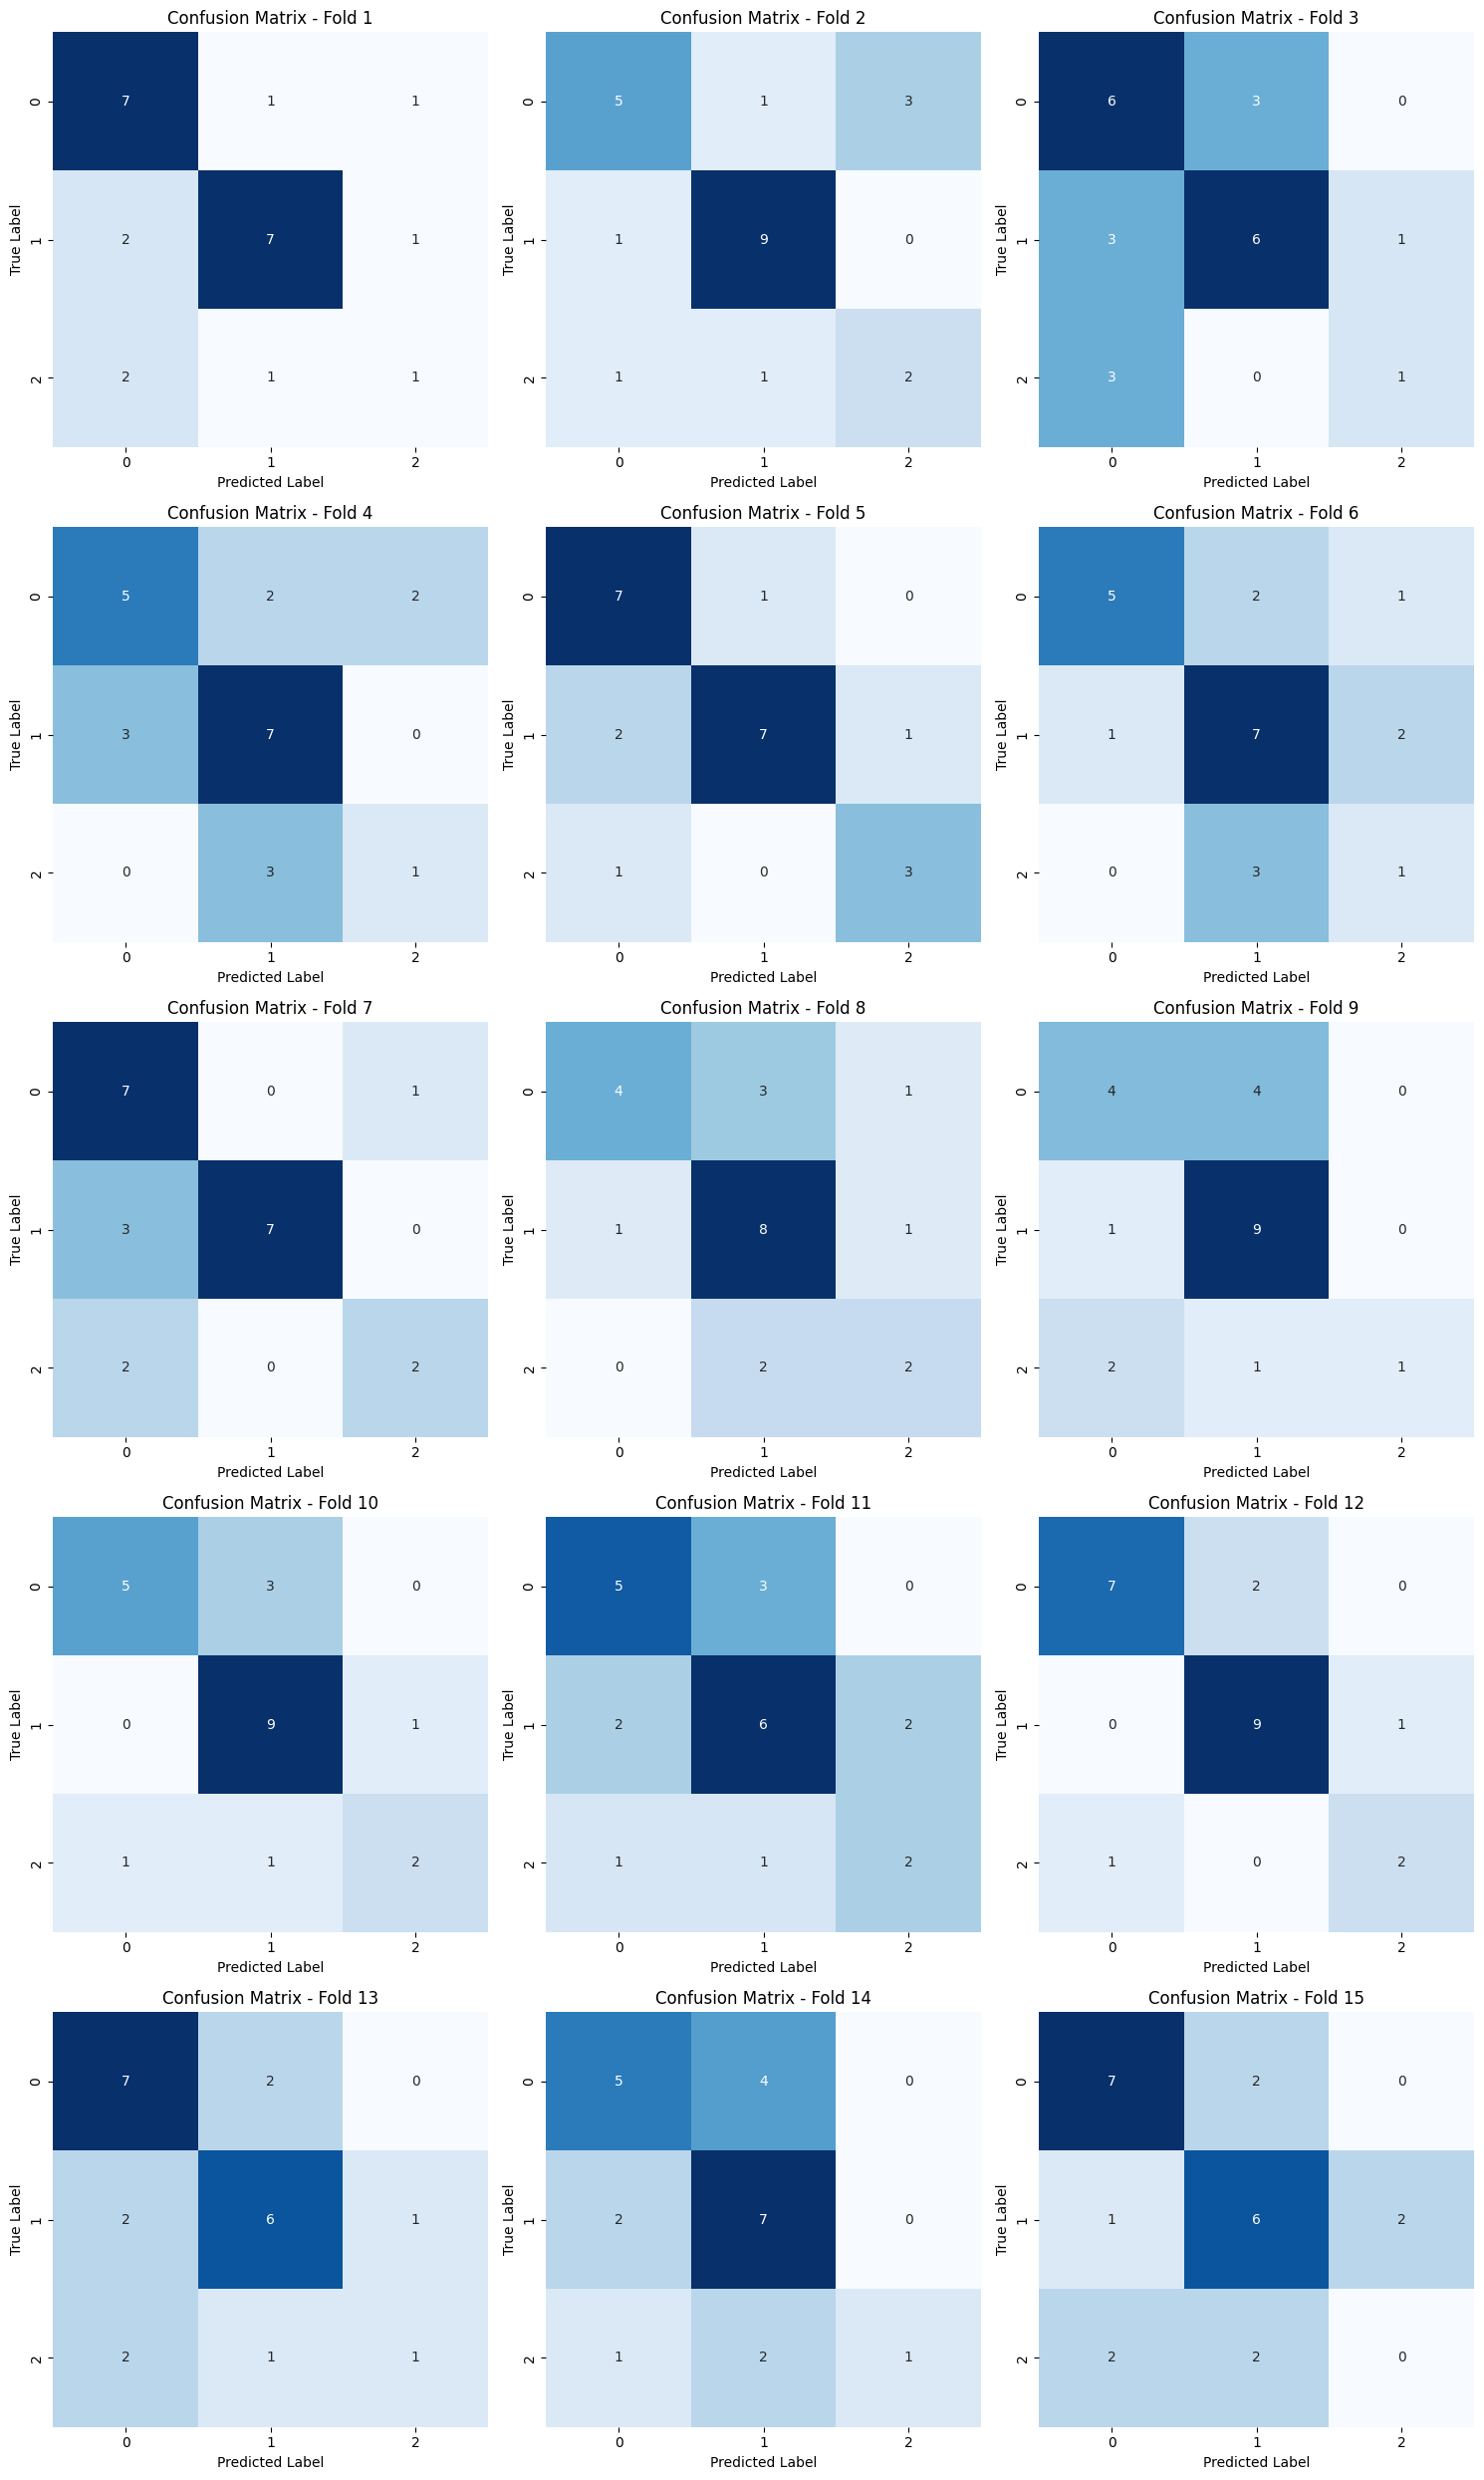

In [24]:
# Confusion Matrix Subplots for Cross-Validation Folds
num_folds = len(fold_metrics['confusion_matrices'])
cols = 3  # Number of columns in the subplot grid
rows = (num_folds // cols) + (num_folds % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # Flatten the axes array for easy indexing

for idx, confusion in enumerate(fold_metrics['confusion_matrices']):
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - Fold {idx + 1}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

# Remove unused subplots if any
for idx in range(len(fold_metrics['confusion_matrices']), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score ,GridSearchCV

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, mean_squared_error)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load dataset (assuming epma2 is already loaded as a DataFrame)
X = epma2.drop(columns=['T'])
y = epma2['T']

# Split into training and test sets(stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Hyperparameter tuning using GridSearchCV
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}


grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid_search.fit(X_train, y_train)

# Best model from grid search
best_model = grid_search.best_estimator_

# Cross-validation to evaluate the model
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_squared_error')
cv_mse = -cv_scores.mean()
print(f"Cross-validated Mean Squared Error: {cv_mse}")

# Train the best model on the full training data
best_model.fit(X_train, y_train)

# Make predictions
y_pred = best_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Output the decision tree structure
from sklearn.tree import export_text
tree_rules = export_text(best_model, feature_names=list(epma2.drop('T', axis = 1).columns))
print(tree_rules)


Cross-validated Mean Squared Error: 0.5335986210183786
Mean Squared Error: 0.5778162081549463
|--- K2O <= 0.10
|   |--- CaO <= -0.17
|   |   |--- MgO <= -0.16
|   |   |   |--- Cr2O3 <= 0.23
|   |   |   |   |--- FeO <= 0.48
|   |   |   |   |   |--- value: [1.24]
|   |   |   |   |--- FeO >  0.48
|   |   |   |   |   |--- value: [2.00]
|   |   |   |--- Cr2O3 >  0.23
|   |   |   |   |--- value: [3.00]
|   |   |--- MgO >  -0.16
|   |   |   |--- Cr2O3 <= 0.84
|   |   |   |   |--- FeO <= 0.26
|   |   |   |   |   |--- value: [1.00]
|   |   |   |   |--- FeO >  0.26
|   |   |   |   |   |--- value: [1.50]
|   |   |   |--- Cr2O3 >  0.84
|   |   |   |   |--- value: [3.00]
|   |--- CaO >  -0.17
|   |   |--- Al2O3 <= -1.73
|   |   |   |--- value: [3.00]
|   |   |--- Al2O3 >  -1.73
|   |   |   |--- CaO <= 1.22
|   |   |   |   |--- SiO2 <= 0.71
|   |   |   |   |   |--- TiO2 <= 2.06
|   |   |   |   |   |   |--- K2O <= 0.00
|   |   |   |   |   |   |   |--- CaO <= 0.92
|   |   |   |   |   |   |   |   |--- 

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Plot the decision tree
plt.figure(figsize=(20,10))
plot_tree(best_model, feature_names=list(X.columns), filled=True, rounded=True, fontsize=12)
plt.show()